# T53 — Global sedimentary basins: inventory, thickness, and paleogeographic reconstruction

**Cluster H: Sedimentary basins.**  *Author-contributed by:* Christian Heine (ICONS Atlas / Interactive Continental Sedimentary Basins Atlas, EarthByte).  *Datasets:* Heine (2007) ICONS basin polygons (870 basins), Bird & Mooney (2026) GST-1 sediment thickness, Afonso et al. (2019) global crustal thickness.

## What this notebook produces

1. **Present-day inventory map** of every sedimentary basin in Christian Heine's 870-basin ICONS Atlas compilation, coloured by maximum sedimentary fill thickness (km).
2. **Sediment-thickness raster** (Bird & Mooney 2026 GST-1, 0.125° global) with the basin polygons overlain — visually confirms that the thickest sediment cover is inside the mapped basins.
3. **Crustal-thickness raster** (Afonso et al. 2019, 0.25° global) with the basin polygons overlain — most extensional basins sit on markedly thinned continental crust.
4. **Per-basin summary table** with both grids sampled inside each polygon: mean sediment thickness, mean crustal thickness, area, and the sediment-to-crust ratio (an easy first-order β-proxy).
5. **Paleogeographic reconstruction** of the basin centroids at a user-chosen deep-time age, showing where today's basins were during (e.g.) Pangea breakup at 200 Ma.

## Learning objectives

- Load a global sedimentary-basin polygon layer with `geopandas`.
- Rasterise a large sediment-thickness compilation for pyGMT rendering.
- Use `pygmt.grdtrack` (or a zonal-mean helper) to sample a raster inside every polygon of a shapefile.
- Compute a first-order stretching-factor proxy (`sed / crust`) from bundled global grids.
- Reconstruct polygon centroids to a paleo age via `gplately.Points` and overlay them on a paleogeographic map.

## Prerequisites and runtime

- **Plate model**: Merdith 2021 in paleomag frame (matches the ICONS Atlas convention). Any paleomag-frame model works via `MODEL_NAME`.
- **Data (bundled)**: `data/basins_icons_heine/BasinsMay2012.shp` (14 MB, 870 basins), `data/sediment_thickness_bird_mooney/Bird_Mooney_GST14_WGS84.nc` (8 MB, 0.125°), `data/crustal_thickness_afonso/crustal-thickness-gmt-surface.nc` (4 MB, 0.25°).
- **Python**: `gplately`, `pygmt`, `pygplates`, `geopandas`, `shapely`, `xarray`, `numpy`, `pandas`.
- **Runtime**: \~1–2 minutes (dominated by the per-basin zonal-mean sampling of the 0.125° sediment grid).


## Environment + imports


In [1]:
from pathlib import Path
import os, sys, warnings
if Path("../data").exists() and not Path("data").exists():
    os.chdir("..")

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import pygmt
import gplately
import pygplates
from plate_model_manager import PlateModelManager

print("Environment")
print(f"  python      {sys.version.split()[0]}")
for _m in (np, pd, xr, gpd, pygmt, gplately, pygplates):
    print(f"  {_m.__name__:11s} {getattr(_m, '__version__', 'n/a')}")


Environment
  python      3.11.15
  numpy       2.4.4
  pandas      3.0.2
  xarray      2026.7.0
  geopandas   1.1.4
  pygmt       v0.17.0
  gplately    2.0.0
  pygplates   1.0.0


## Configuration


In [2]:
# === USER CONFIGURATION =====================================================
MODEL_NAME             = "Merdith2021"
ANCHOR_PLATE_ID        = 0                # Merdith2021 default rotation = paleomag frame

# Paleo age at which basin centroids are reconstructed on the paleogeographic map.
PALEO_AGE_MA           = 200.0            # Early Jurassic — Pangea breakup context

# Bundled datasets.
BASINS_SHP             = Path(os.environ.get("ZENODO_BASINS_ICONS_DIR", "zenodo_data/ICONS_sedimentary_basins_Heine")) / "BasinsMay2012.shp"
SED_THK_NC             = Path(os.environ.get("ZENODO_SEDTHICK_DIR", "zenodo_data/sediment_thickness_BirdMooney")) / "Bird_Mooney_GST14_WGS84.nc"
CRUST_THK_NC           = Path(os.environ.get("ZENODO_CRUSTTHICK_DIR", "zenodo_data/crustal_thickness_Afonso")) / "crustal-thickness-gmt-surface.nc"

# Map layout.
REGION, PROJ           = [-180, 180, -75, 80], "R0/22c"     # Winkel Tripel, 22 cm wide
# ============================================================================
print(f"  plate model:      {MODEL_NAME}  (anchor {ANCHOR_PLATE_ID})")
print(f"  paleo age:        {PALEO_AGE_MA:.0f} Ma")
print(f"  basins shp:       {BASINS_SHP}")
print(f"  sediment grid:    {SED_THK_NC}")
print(f"  crust grid:       {CRUST_THK_NC}")


  plate model:      Merdith2021  (anchor 0)
  paleo age:        200 Ma
  basins shp:       data/basins_icons_heine/BasinsMay2012.shp
  sediment grid:    data/sediment_thickness_bird_mooney/Bird_Mooney_GST14_WGS84.nc
  crust grid:       data/crustal_thickness_afonso/crustal-thickness-gmt-surface.nc


## 1. Load basin polygons + sediment and crustal thickness grids


In [3]:
basins = gpd.read_file(BASINS_SHP)
print(f"  {len(basins)} basins in the ICONS Atlas compilation")
print(f"  columns: {list(basins.columns)}")
print(f"  MAX_FILLKM range: {basins['MAX_FILLKM'].min()}–{basins['MAX_FILLKM'].max()} km")

sed_da = xr.open_dataarray(SED_THK_NC)
print(f"\n  sediment grid: {sed_da.shape}, extent {sed_da.lon.min().item():.1f} to "
      f"{sed_da.lon.max().item():.1f} lon, {sed_da.lat.min().item():.1f} to {sed_da.lat.max().item():.1f} lat")
print(f"  sediment thickness range: 0 – {int(sed_da.max())} m")

crust_ds = xr.open_dataset(CRUST_THK_NC)
crust_da = crust_ds["z"] if "z" in crust_ds else list(crust_ds.data_vars.values())[0]
if "lon" not in crust_da.dims:
    crust_da = crust_da.rename({d: d.lower() for d in crust_da.dims
                                 if d.lower() in ("lon", "lat")})
# Afonso 2019 NC stores crustal thickness in METRES — convert to km for
# downstream β and per-basin reporting.
crust_da = crust_da / 1000.0
crust_da.attrs["units"] = "km"
print(f"\n  crustal thickness grid: {crust_da.shape}")
print(f"  crustal thickness range: {float(crust_da.min()):.1f} – {float(crust_da.max()):.1f} km")


  870 basins in the ICONS Atlas compilation
  columns: ['OBJECTID', 'SYMBOL', 'BASIN_NAME', 'REG_TL_NAM', 'AREA_KM2', 'MAX_FILLKM', 'SUB_REGIME', 'BASIN_ID', 'SUBREGCODE', 'REG_TL_ABV', 'OWNER', 'AVAILABLE', 'SUBREG_GRP', 'Shape_Leng', 'Shape_Area', 'geometry']
  MAX_FILLKM range: 0.0–23.0 km

  sediment grid: (1441, 2881), extent -180.0 to 180.0 lon, -90.0 to 90.0 lat


  sediment thickness range: 0 – 20118 m

  crustal thickness grid: (721, 1441)
  crustal thickness range: 0.0 – 75.3 km


## 2. Panel A — modern-day inventory map: basins coloured by maximum sedimentary fill (km)


In [ ]:
# CPT capped at 15 km to match §3 Bird & Mooney raster. 18 of 870 basins
# exceed 15 km (Precaspian 23, Scotian Shelf 20, Donbas 20, ...). Those are
# saturated at the top-end colour and the +ef overflow arrow on the colourbar
# indicates the values continue beyond 15 km.
_FILL_CAP_KM = 15.0

import tempfile
_fd, basin_cpt = tempfile.mkstemp(suffix=".cpt", prefix="T75_basin_fill_")
os.close(_fd)
pygmt.makecpt(cmap="lajolla", series=[0, _FILL_CAP_KM, 1],
              reverse=True, output=basin_cpt)

# lajolla ramp endpoints, sampled from GMT's lajolla palette. Reversed so
# thin sediment = pale, thick sediment = dark orange/brown.
def _lajolla_rgb_for(fill_km):
    """Return an (r, g, b) triplet interpolating the same colours the CPT
    uses. Values above the cap saturate at the top-end colour so the polygon
    fill is consistent with the +ef overflow arrow on the colourbar."""
    _t = min(max(fill_km, 0.0) / _FILL_CAP_KM, 1.0)
    r = int(245 + (128 - 245) * _t)
    g = int(230 + (10  - 230) * _t)
    b = int(120 + (30  - 120) * _t)
    return (r, g, b)

fig = pygmt.Figure()
# Locally-scoped: push the lat/lon tick labels further from the frame so
# they stop crowding the axis (default MAP_ANNOT_OFFSET_PRIMARY = 5p is too
# tight at this 22 cm map width). Scoped to just this basemap call so it
# doesn't change tick-label spacing on the colorbar drawn below.
with pygmt.config(MAP_ANNOT_OFFSET_PRIMARY="0.4c"):
    fig.basemap(region=REGION, projection=PROJ, frame="af")
fig.coast(land="gray95", shorelines="0.3p,gray45")

_n_saturated = 0
for _, row in basins.iterrows():
    fill_km = row["MAX_FILLKM"]
    if not np.isfinite(fill_km): fill_km = 0.0
    if fill_km > _FILL_CAP_KM: _n_saturated += 1
    geom = row.geometry
    if geom is None or geom.is_empty: continue
    parts = geom.geoms if geom.geom_type == "MultiPolygon" else [geom]
    r, g, b = _lajolla_rgb_for(fill_km)
    for part in parts:
        x, y = part.exterior.xy
        fig.plot(x=list(x), y=list(y), fill=f"{r}/{g}/{b}",
                 pen="0.15p,black", close=True, transparency=15)
print(f"  {_n_saturated} basins exceed the {_FILL_CAP_KM:.0f} km cap and "
      f"saturate at the top-end colour (see +ef overflow arrow on colourbar)")

# Colorbar with +ef right-hand overflow arrow (values continue > 15 km)
fig.colorbar(cmap=basin_cpt,
             position="JBC+w12c/0.35c+h+o0/1c+ef",
             frame=["a5f1", "x+lMaximum sedimentary fill (km)"])
fig.text(text=f"ICONS Atlas: {len(basins)} sedimentary basins (colour = MAX_FILLKM)",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
fig.show(width=1000)


## 3. Panel B — Bird & Mooney (2026) sediment thickness raster + basin outlines


grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


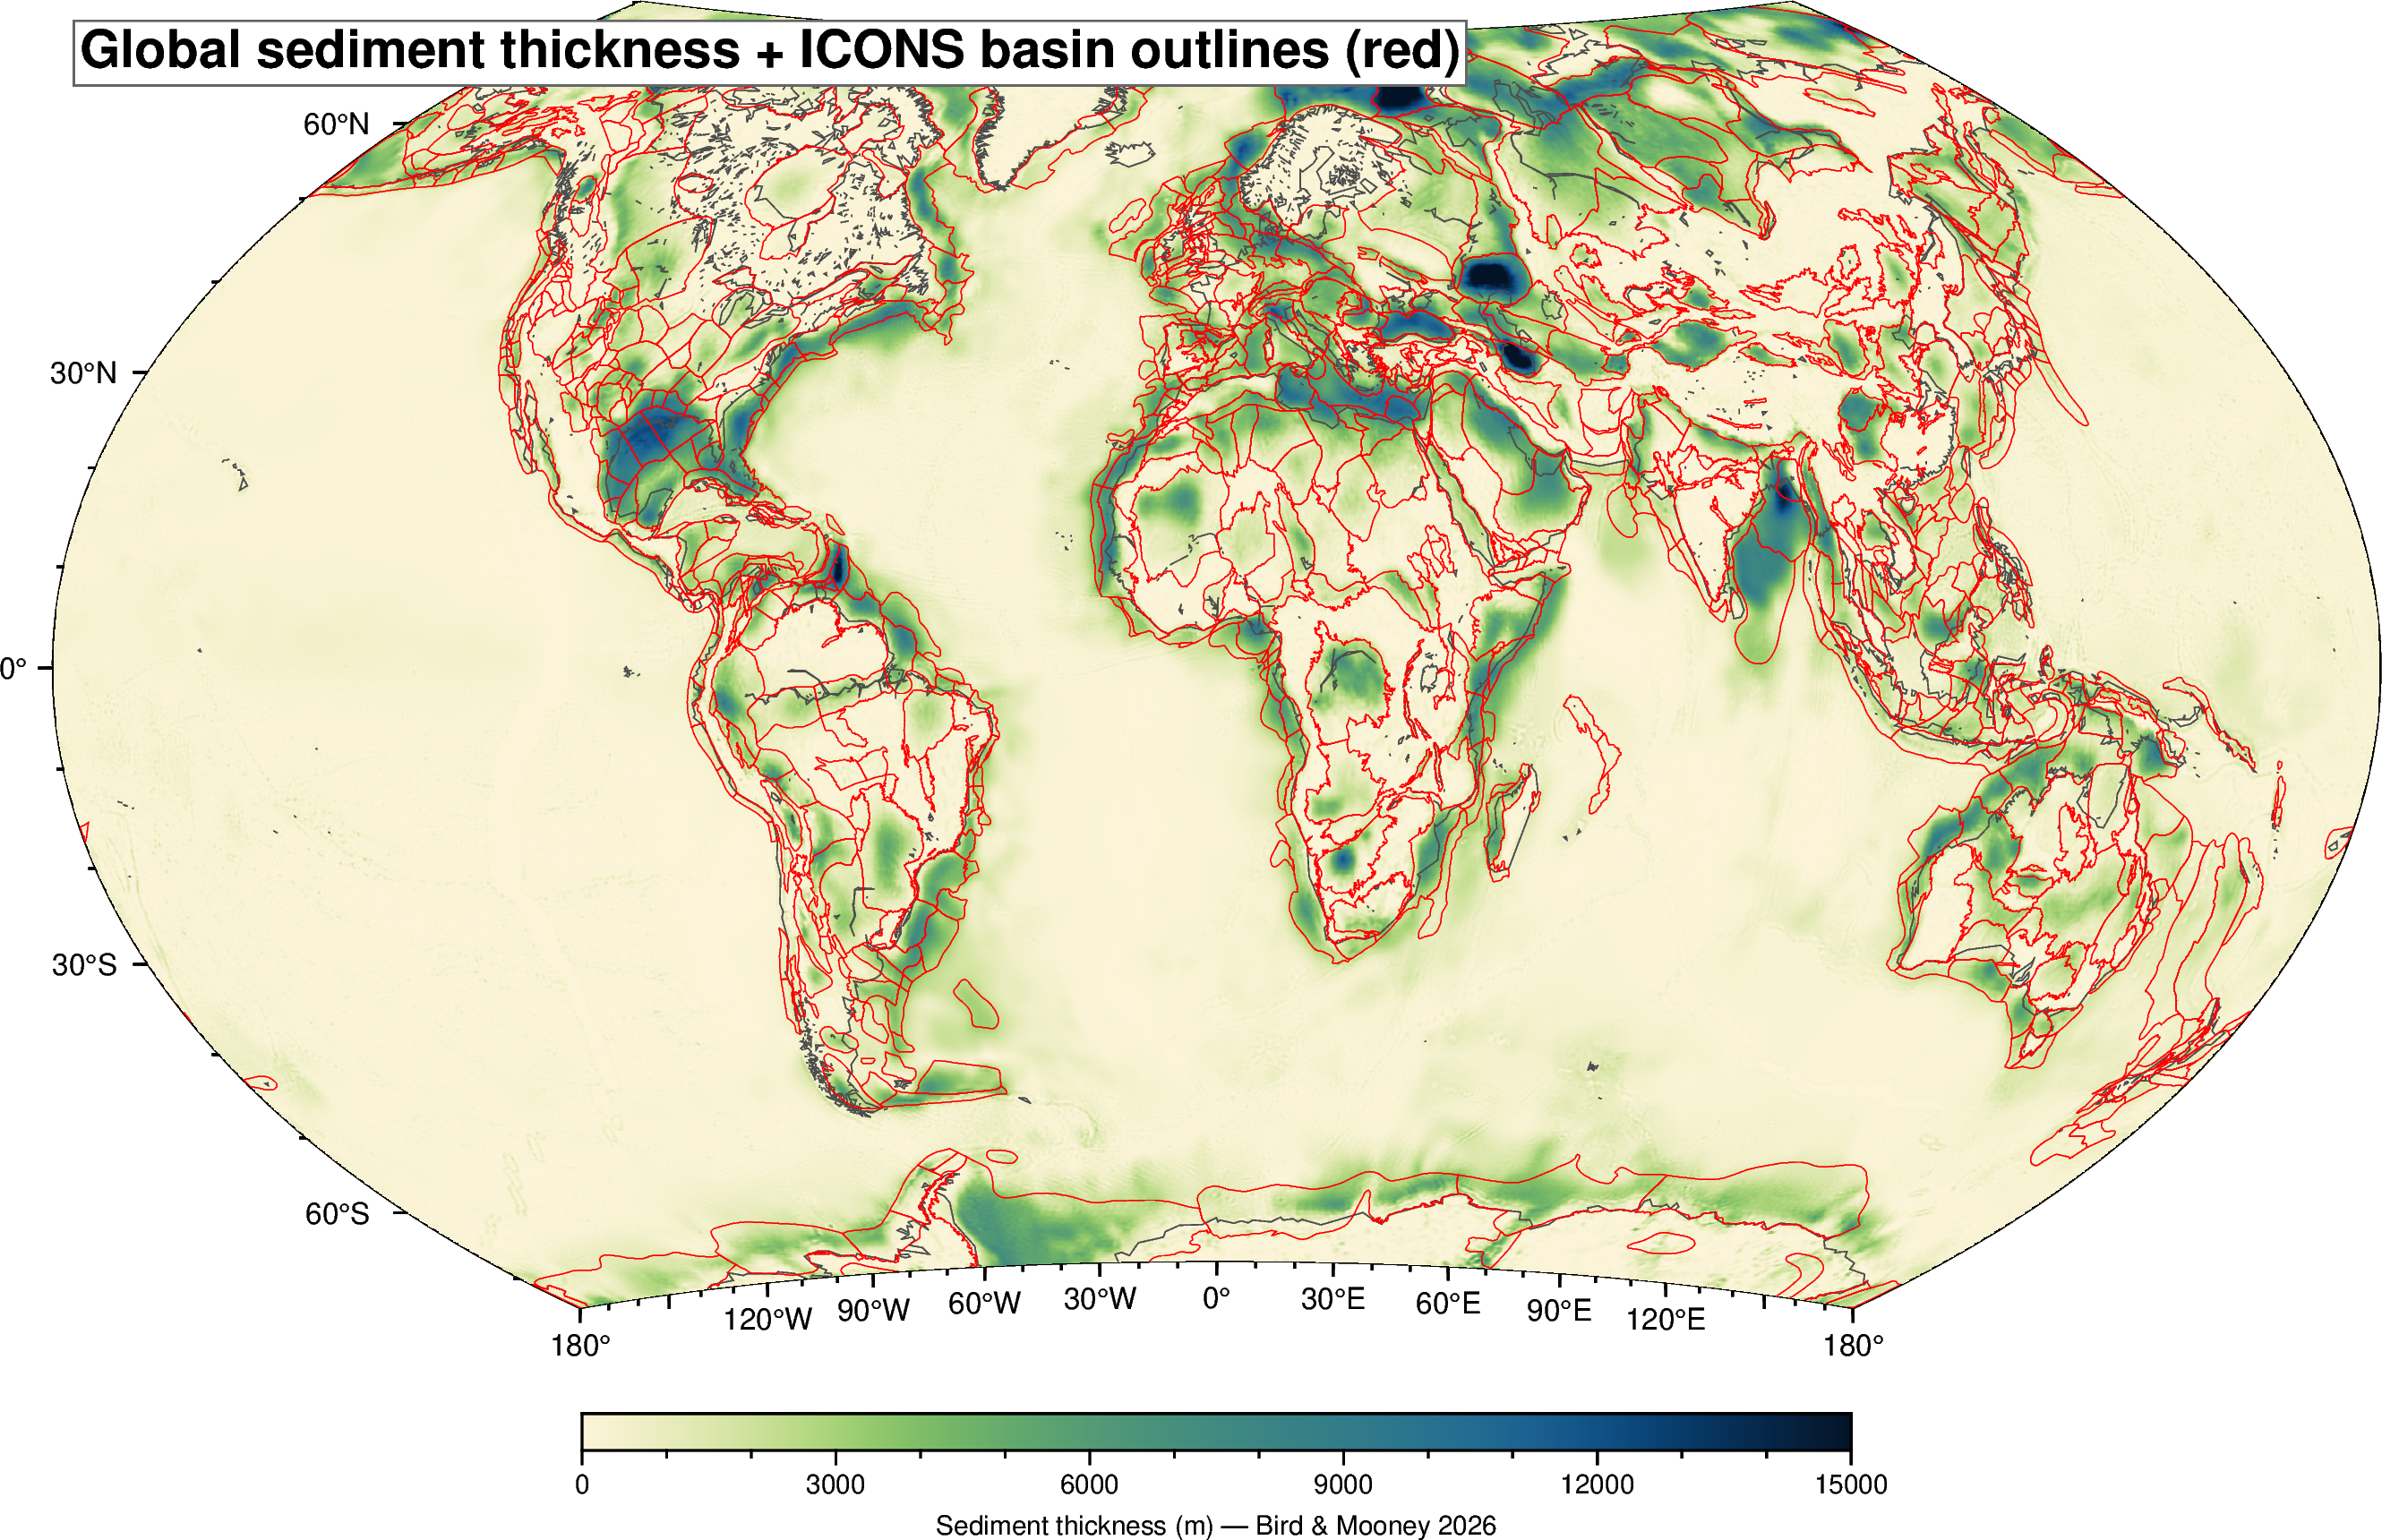

In [5]:
fig = pygmt.Figure()
fig.basemap(region=REGION, projection=PROJ, frame="af")
# GMT expects (y, x) dim order for grdimage — Bird & Mooney is already (lat, lon)
pygmt.makecpt(cmap="navia", series=[0, 15000, 250], reverse=True, continuous=True)
fig.grdimage(grid=sed_da, cmap=True, nan_transparent=True)
fig.coast(land=None, shorelines="0.3p,gray30")

# Overlay basin outlines
for _, row in basins.iterrows():
    geom = row.geometry
    if geom is None or geom.is_empty: continue
    parts = geom.geoms if geom.geom_type == "MultiPolygon" else [geom]
    for part in parts:
        x, y = part.exterior.xy
        fig.plot(x=list(x), y=list(y), pen="0.25p,red", close=True)

fig.colorbar(frame=["a3000f1000", "x+lSediment thickness (m) — Bird & Mooney 2026"],
             position="JBC+w12c/0.35c+h+o0/1c")
fig.text(text="Global sediment thickness + ICONS basin outlines (red)",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
fig.show(width=1000)


## 4. Panel C — Afonso et al. (2019) crustal thickness raster + basin outlines


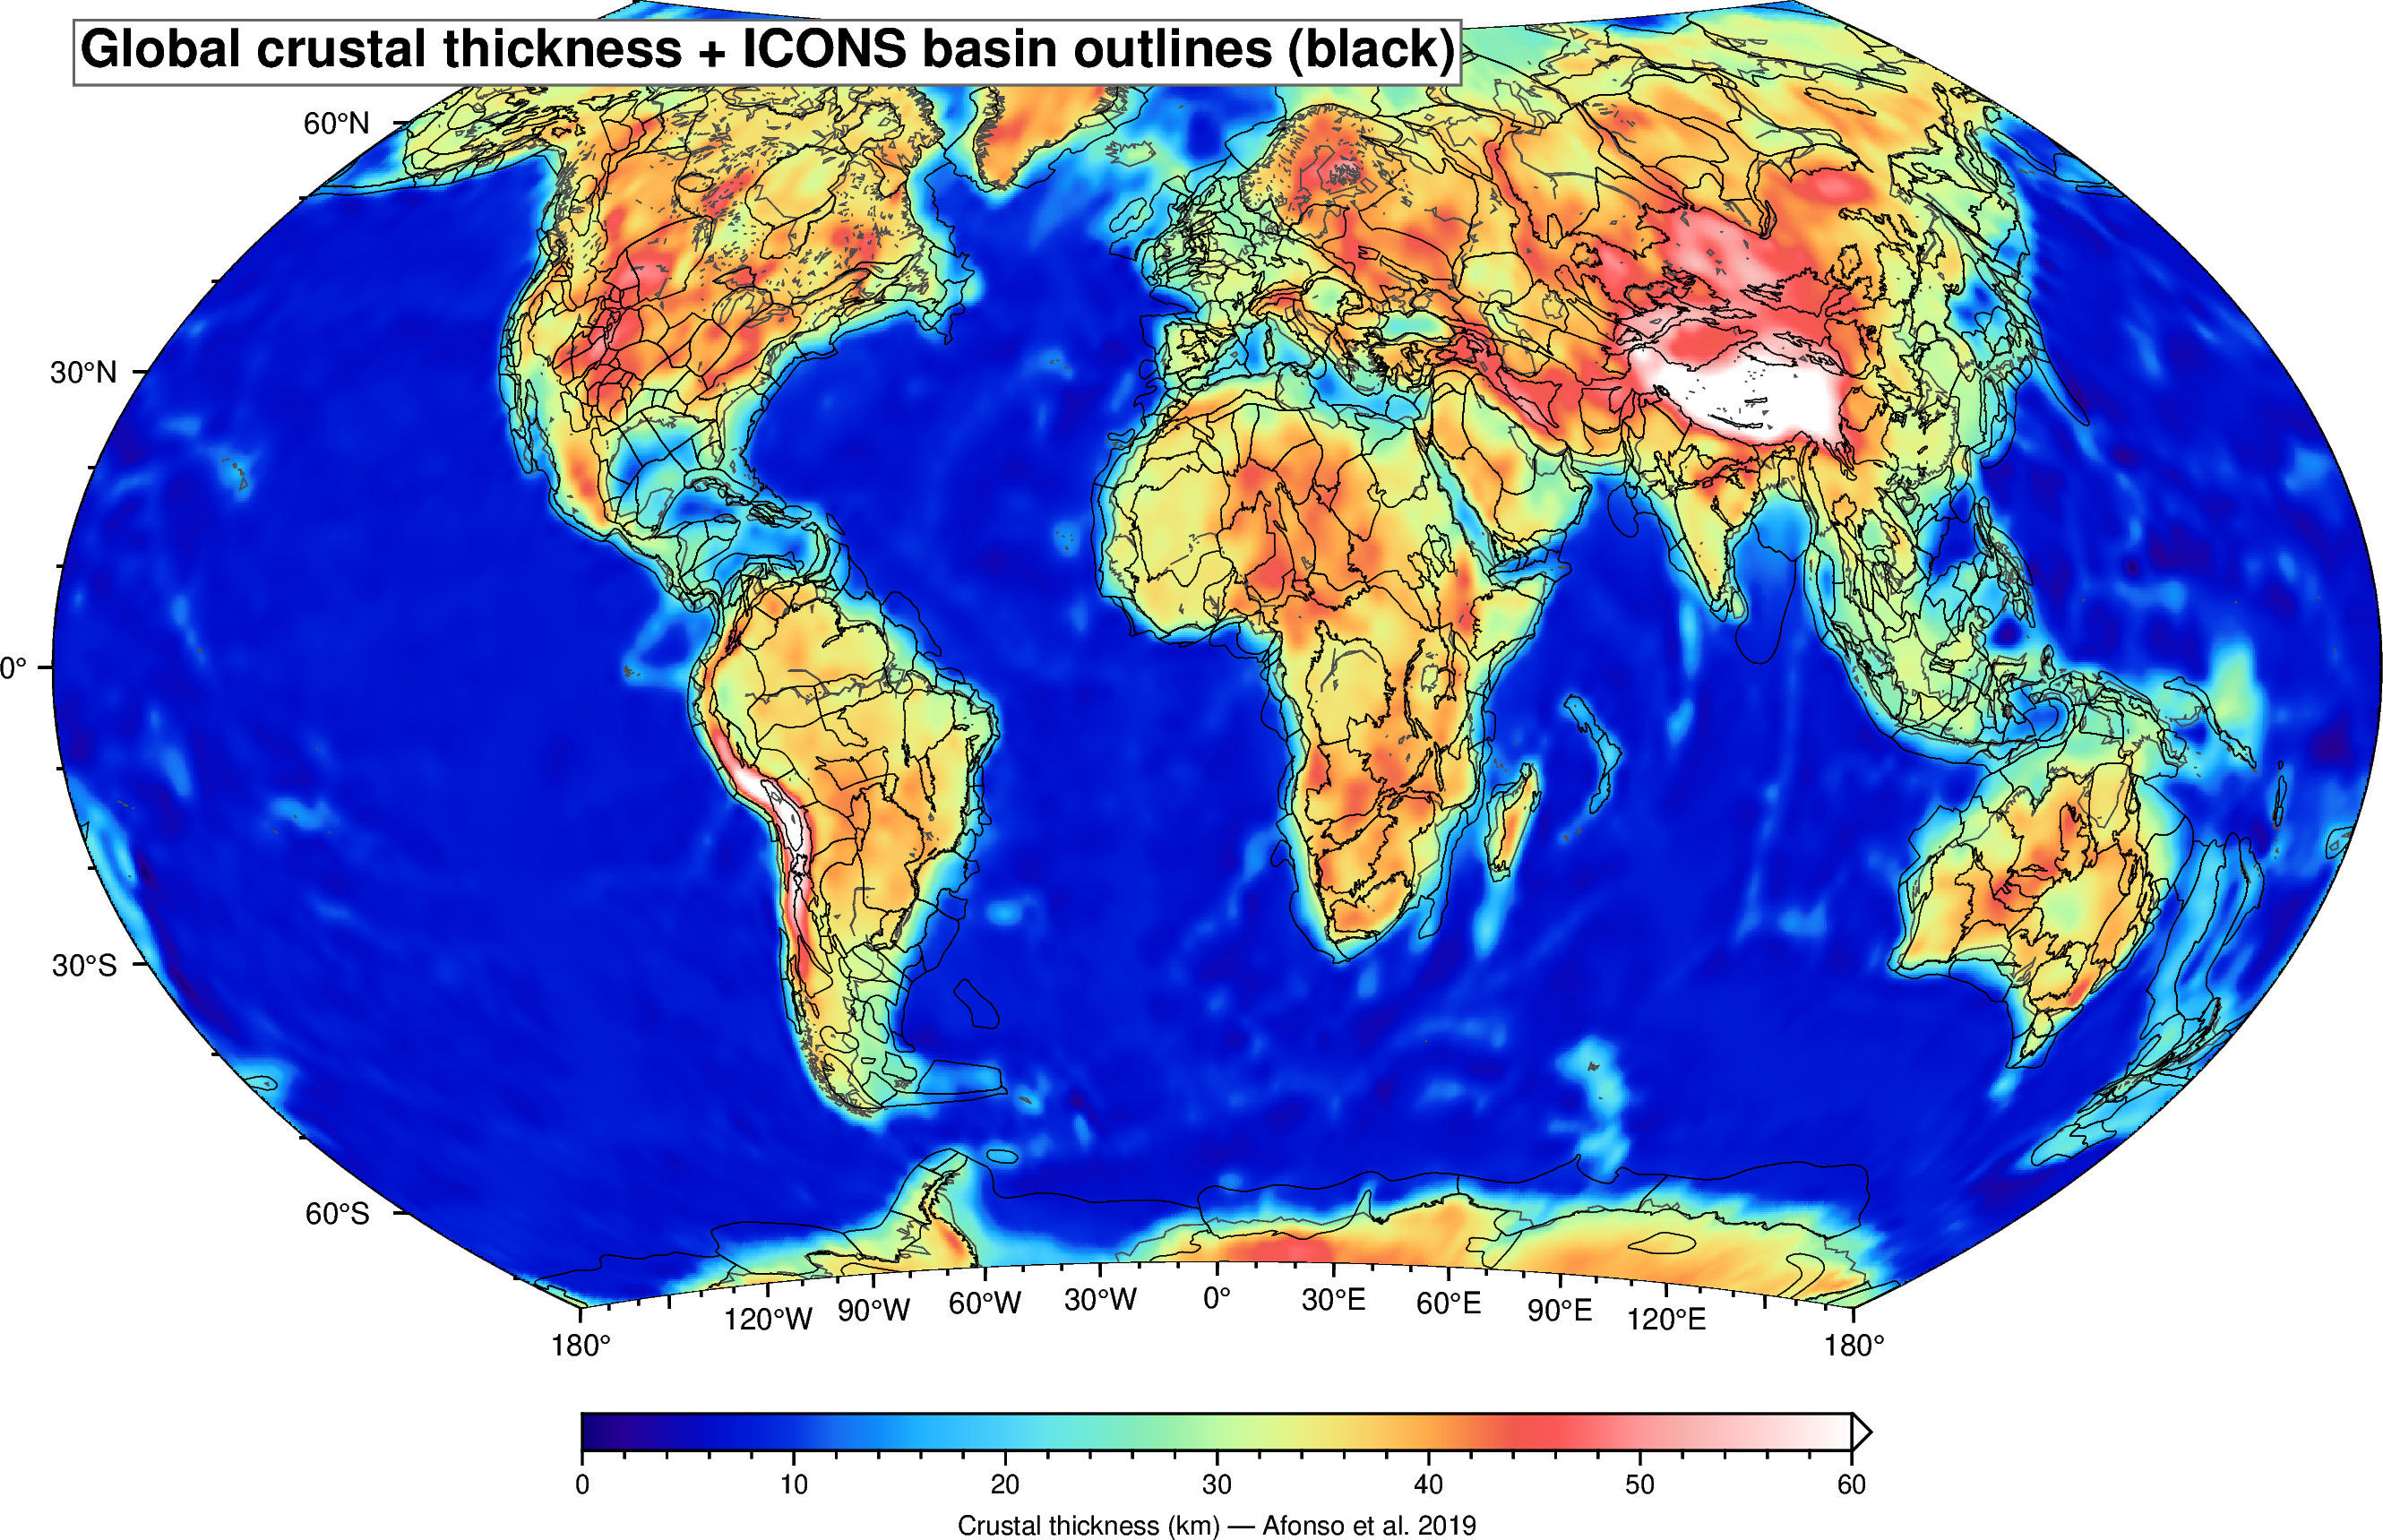

In [6]:
fig = pygmt.Figure()
fig.basemap(region=REGION, projection=PROJ, frame="af")
# CPT capped at 60 km with +ef overflow arrow — a small number of cells
# (thick Andean / Tibetan / Himalayan roots) exceed 60 km and saturate at
# the top-end colour; the arrow flags that data continue beyond the cap.
pygmt.makecpt(cmap="haxby", series=[0, 60, 2], continuous=True)
fig.grdimage(grid=crust_da, cmap=True, nan_transparent=True)
fig.coast(land=None, shorelines="0.3p,gray30")

# Overlay basin outlines
for _, row in basins.iterrows():
    geom = row.geometry
    if geom is None or geom.is_empty: continue
    parts = geom.geoms if geom.geom_type == "MultiPolygon" else [geom]
    for part in parts:
        x, y = part.exterior.xy
        fig.plot(x=list(x), y=list(y), pen="0.25p,black", close=True)

fig.colorbar(frame=["a10f2", "x+lCrustal thickness (km) — Afonso et al. 2019"],
             position="JBC+w12c/0.35c+h+o0/1c+ef")
fig.text(text="Global crustal thickness + ICONS basin outlines (black)",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
fig.show(width=1000)


## 5. Per-basin zonal means — sample both grids inside every basin polygon

For each of the 870 basins we compute the mean sediment thickness (Bird & Mooney) and mean crustal thickness (Afonso) inside the polygon. The ratio sed/(crust × 1000) is a first-order proxy for extensional stretching.

In [7]:
from shapely.vectorized import contains

def _zonal_mean(da: xr.DataArray, geom) -> float:
    """Mean value of the DataArray inside the shapely polygon."""
    if geom is None or geom.is_empty: return np.nan
    minx, miny, maxx, maxy = geom.bounds
    sub = da.sel(lon=slice(minx, maxx), lat=slice(miny, maxy))
    if sub.size == 0: return np.nan
    LON, LAT = np.meshgrid(sub.lon.values, sub.lat.values)
    mask = contains(geom, LON, LAT)
    vals = sub.values[mask]
    vals = vals[np.isfinite(vals)]
    return float(vals.mean()) if vals.size else np.nan

sed_mean, crust_mean = [], []
for i, row in basins.iterrows():
    sed_mean.append(_zonal_mean(sed_da, row.geometry))
    crust_mean.append(_zonal_mean(crust_da, row.geometry))
    if (i + 1) % 200 == 0:
        print(f"  processed {i+1} of {len(basins)} basins")

basins["sed_thk_mean_m"]   = sed_mean
basins["crust_thk_mean_km"] = crust_mean
# Simple stretching-factor proxy: sediment thickness as a fraction of crustal thickness.
# Bigger = more sediment relative to (thinned) crust.
basins["sed_over_crust"] = (basins["sed_thk_mean_m"] / 1000) / basins["crust_thk_mean_km"]

print(f"\n  sampled sediment thickness — mean {basins['sed_thk_mean_m'].mean():.0f} m, "
      f"max {basins['sed_thk_mean_m'].max():.0f} m")
print(f"  sampled crustal thickness — mean {basins['crust_thk_mean_km'].mean():.1f} km, "
      f"min {basins['crust_thk_mean_km'].min():.1f} km")

# Show the top 15 thickest-sediment basins
print("\n  top 15 basins by mean sediment thickness:")
print(basins.nlargest(15, "sed_thk_mean_m")
            [["BASIN_NAME", "REG_TL_NAM", "AREA_KM2",
              "MAX_FILLKM", "sed_thk_mean_m", "crust_thk_mean_km"]]
            .to_string(index=False))


/tmp/ipykernel_17734/1105684911.py:10: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).


  processed 200 of 870 basins


  processed 400 of 870 basins


  processed 600 of 870 basins


  processed 800 of 870 basins



  sampled sediment thickness — mean 2224 m, max 11331 m
  sampled crustal thickness — mean 29.3 km, min 7.9 km

  top 15 basins by mean sediment thickness:
              BASIN_NAME                       REG_TL_NAM  AREA_KM2  MAX_FILLKM  sed_thk_mean_m  crust_thk_mean_km
           South Caspian               Central Paratethys  246032.0        20.0    11331.255859          39.359582
              Precaspian               Central Paratethys  583301.0        23.0    10673.798828          35.060402
West Gulf Coast Tertiary                   Gulf of Mexico  305124.0        16.0    10491.408203          23.011966
                Barbados               Southern Caribbean  133561.0        18.0    10490.568359          16.346343
        East Barents Sea West Siberia and European Arctic  668406.0        20.0     9665.995117          27.300617
East Gulf Coast Tertiary                   Gulf of Mexico  344558.0        16.0     9623.342773          26.834178
              Nile Delta              

## 6. Basin count + total area by REG_TL_NAM (regional grouping)


  65 regional groups
                                 n_basins  total_area_km2  mean_fill_km
REG_TL_NAM                                                             
Circum-South Atlantic (America)        31       3433158.0      5.096774
Southern Caribbean                     30       1774915.0      8.466667
Eastern Indonesia                      28       2525894.0      4.535714
India and the Seychelles               25       4145304.0      6.160000
Pacific Far East                       24       1916014.0      0.250000
Indo-China                             22       2553647.0      7.590909
North America Rockies                  22       1276211.0      0.000000
Western Indonesia                      21       3051839.0      5.095238
Middle East                            21       7291877.0     10.142857
Sub-Andean                             20       3591399.0      7.200000
Western Europe                         20        906213.0      0.600000
South America Interior                 19  

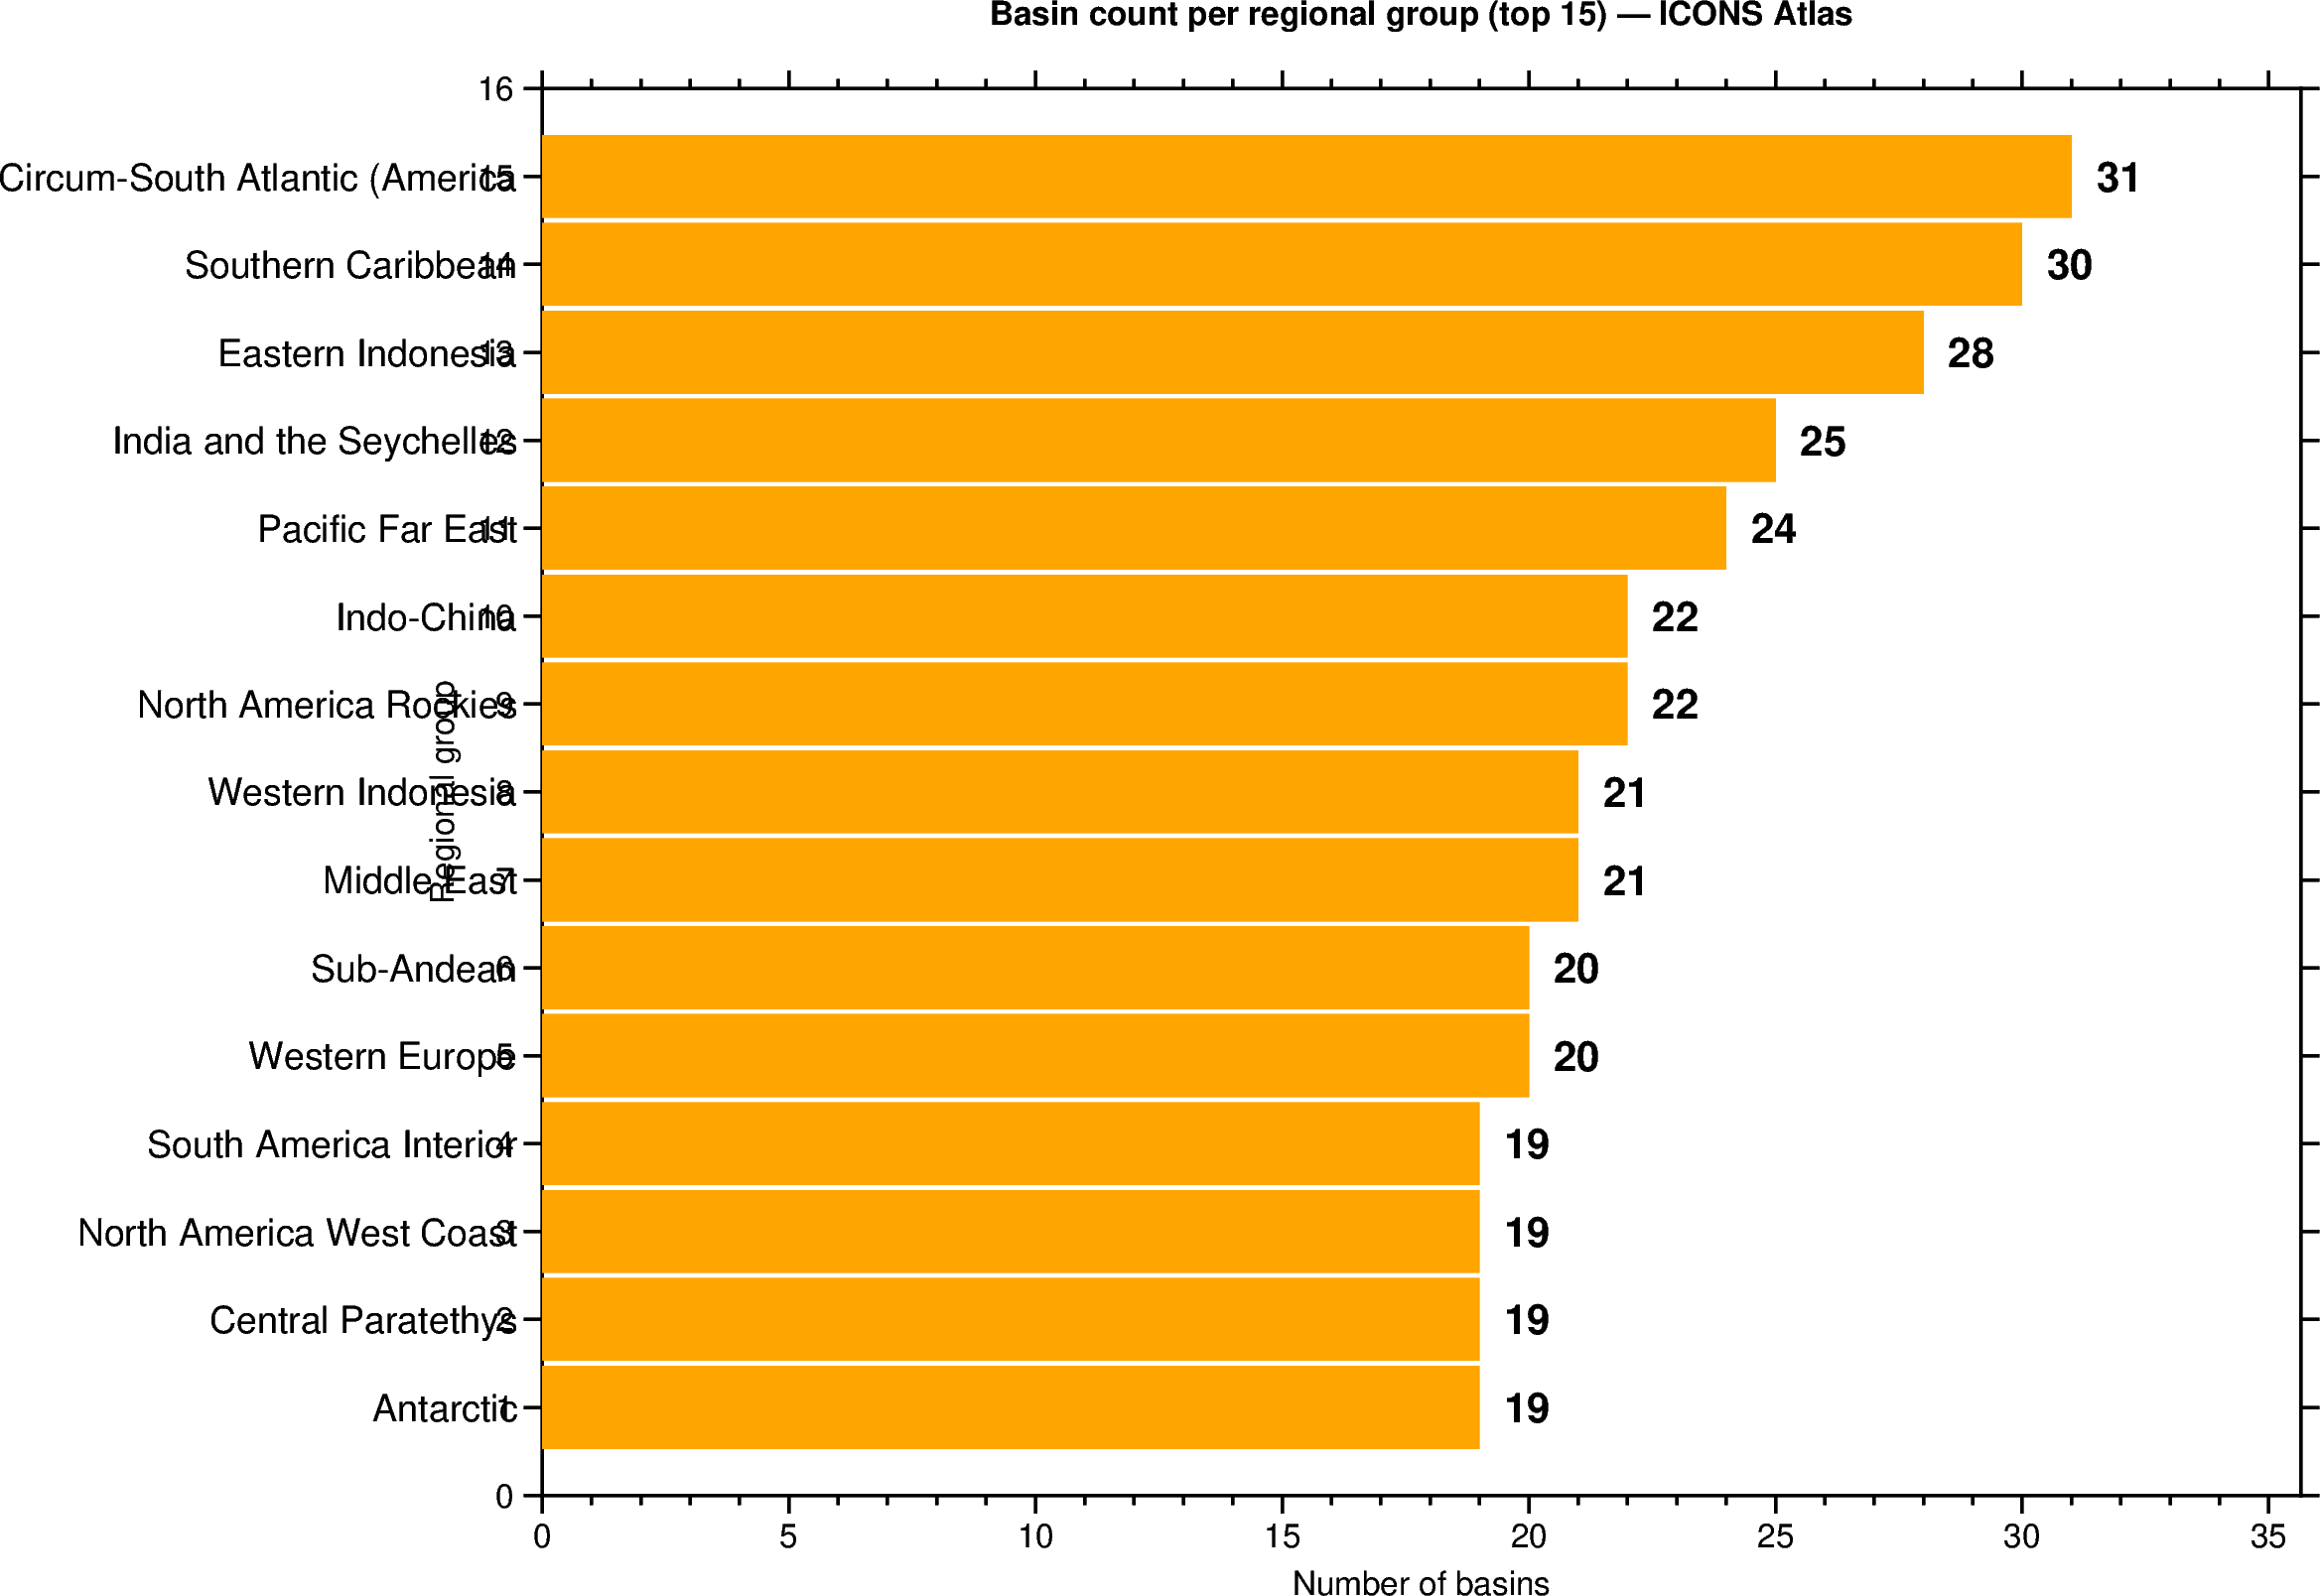

In [8]:
grp = (basins.groupby("REG_TL_NAM")
              .agg(n_basins=("BASIN_ID", "size"),
                   total_area_km2=("AREA_KM2", "sum"),
                   mean_fill_km=("MAX_FILLKM", "mean"))
              .sort_values("n_basins", ascending=False))
print(f"  {len(grp)} regional groups")
print(grp.head(15).to_string())

# Horizontal bar chart — top 15 regions by basin count.
top15 = grp.head(15).reset_index()
y     = np.arange(len(top15))[::-1] + 1     # y positions (top row = row 1)
x_max = top15["n_basins"].max() * 1.15
fig = pygmt.Figure()
fig.basemap(region=[0, x_max, 0, len(top15) + 1],
            projection="X15c/12c",
            frame=["WSne+tBasin count per regional group (top 15) — ICONS Atlas",
                   "xaf+lNumber of basins",
                   "ya1+lRegional group"])
for xi, yi, name in zip(top15["n_basins"], y, top15["REG_TL_NAM"]):
    fig.plot(x=[0, xi], y=[yi, yi], pen="20p,orange")
    fig.text(x=xi + 0.5, y=yi, text=f"{int(xi)}",
             justify="ML", font="10p,Helvetica-Bold,black")
    fig.text(x=-0.5, y=yi, text=name[:30],
             justify="MR", font="9p,Helvetica,black", no_clip=True)
fig.show(width=1000)


## 7. Paleogeographic reconstruction — basin centroids at PALEO_AGE_MA

Reconstruct every basin's centroid to `PALEO_AGE_MA` via `gplately.Points` on the chosen plate model. Sizes on the map are proportional to log(basin area); colour is MAX_FILLKM. The reconstruction reveals where today's basins were during the Pangea breakup epoch (200 Ma), the mid-Cretaceous plate reorganisation (100 Ma), or any other user-chosen slice.

/tmp/ipykernel_17734/101878571.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

/tmp/ipykernel_17734/101878571.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



  PlatePartitioner ready with 2391 static polygons
  assigning plate IDs to 870 basin centroids...


  0 of 870 basins on plate 0 (true stationary anchor)


  760 of 870 basin centroids on paleo-continental crust at 200 Ma (dropped 110 offshore/oceanic-crust)


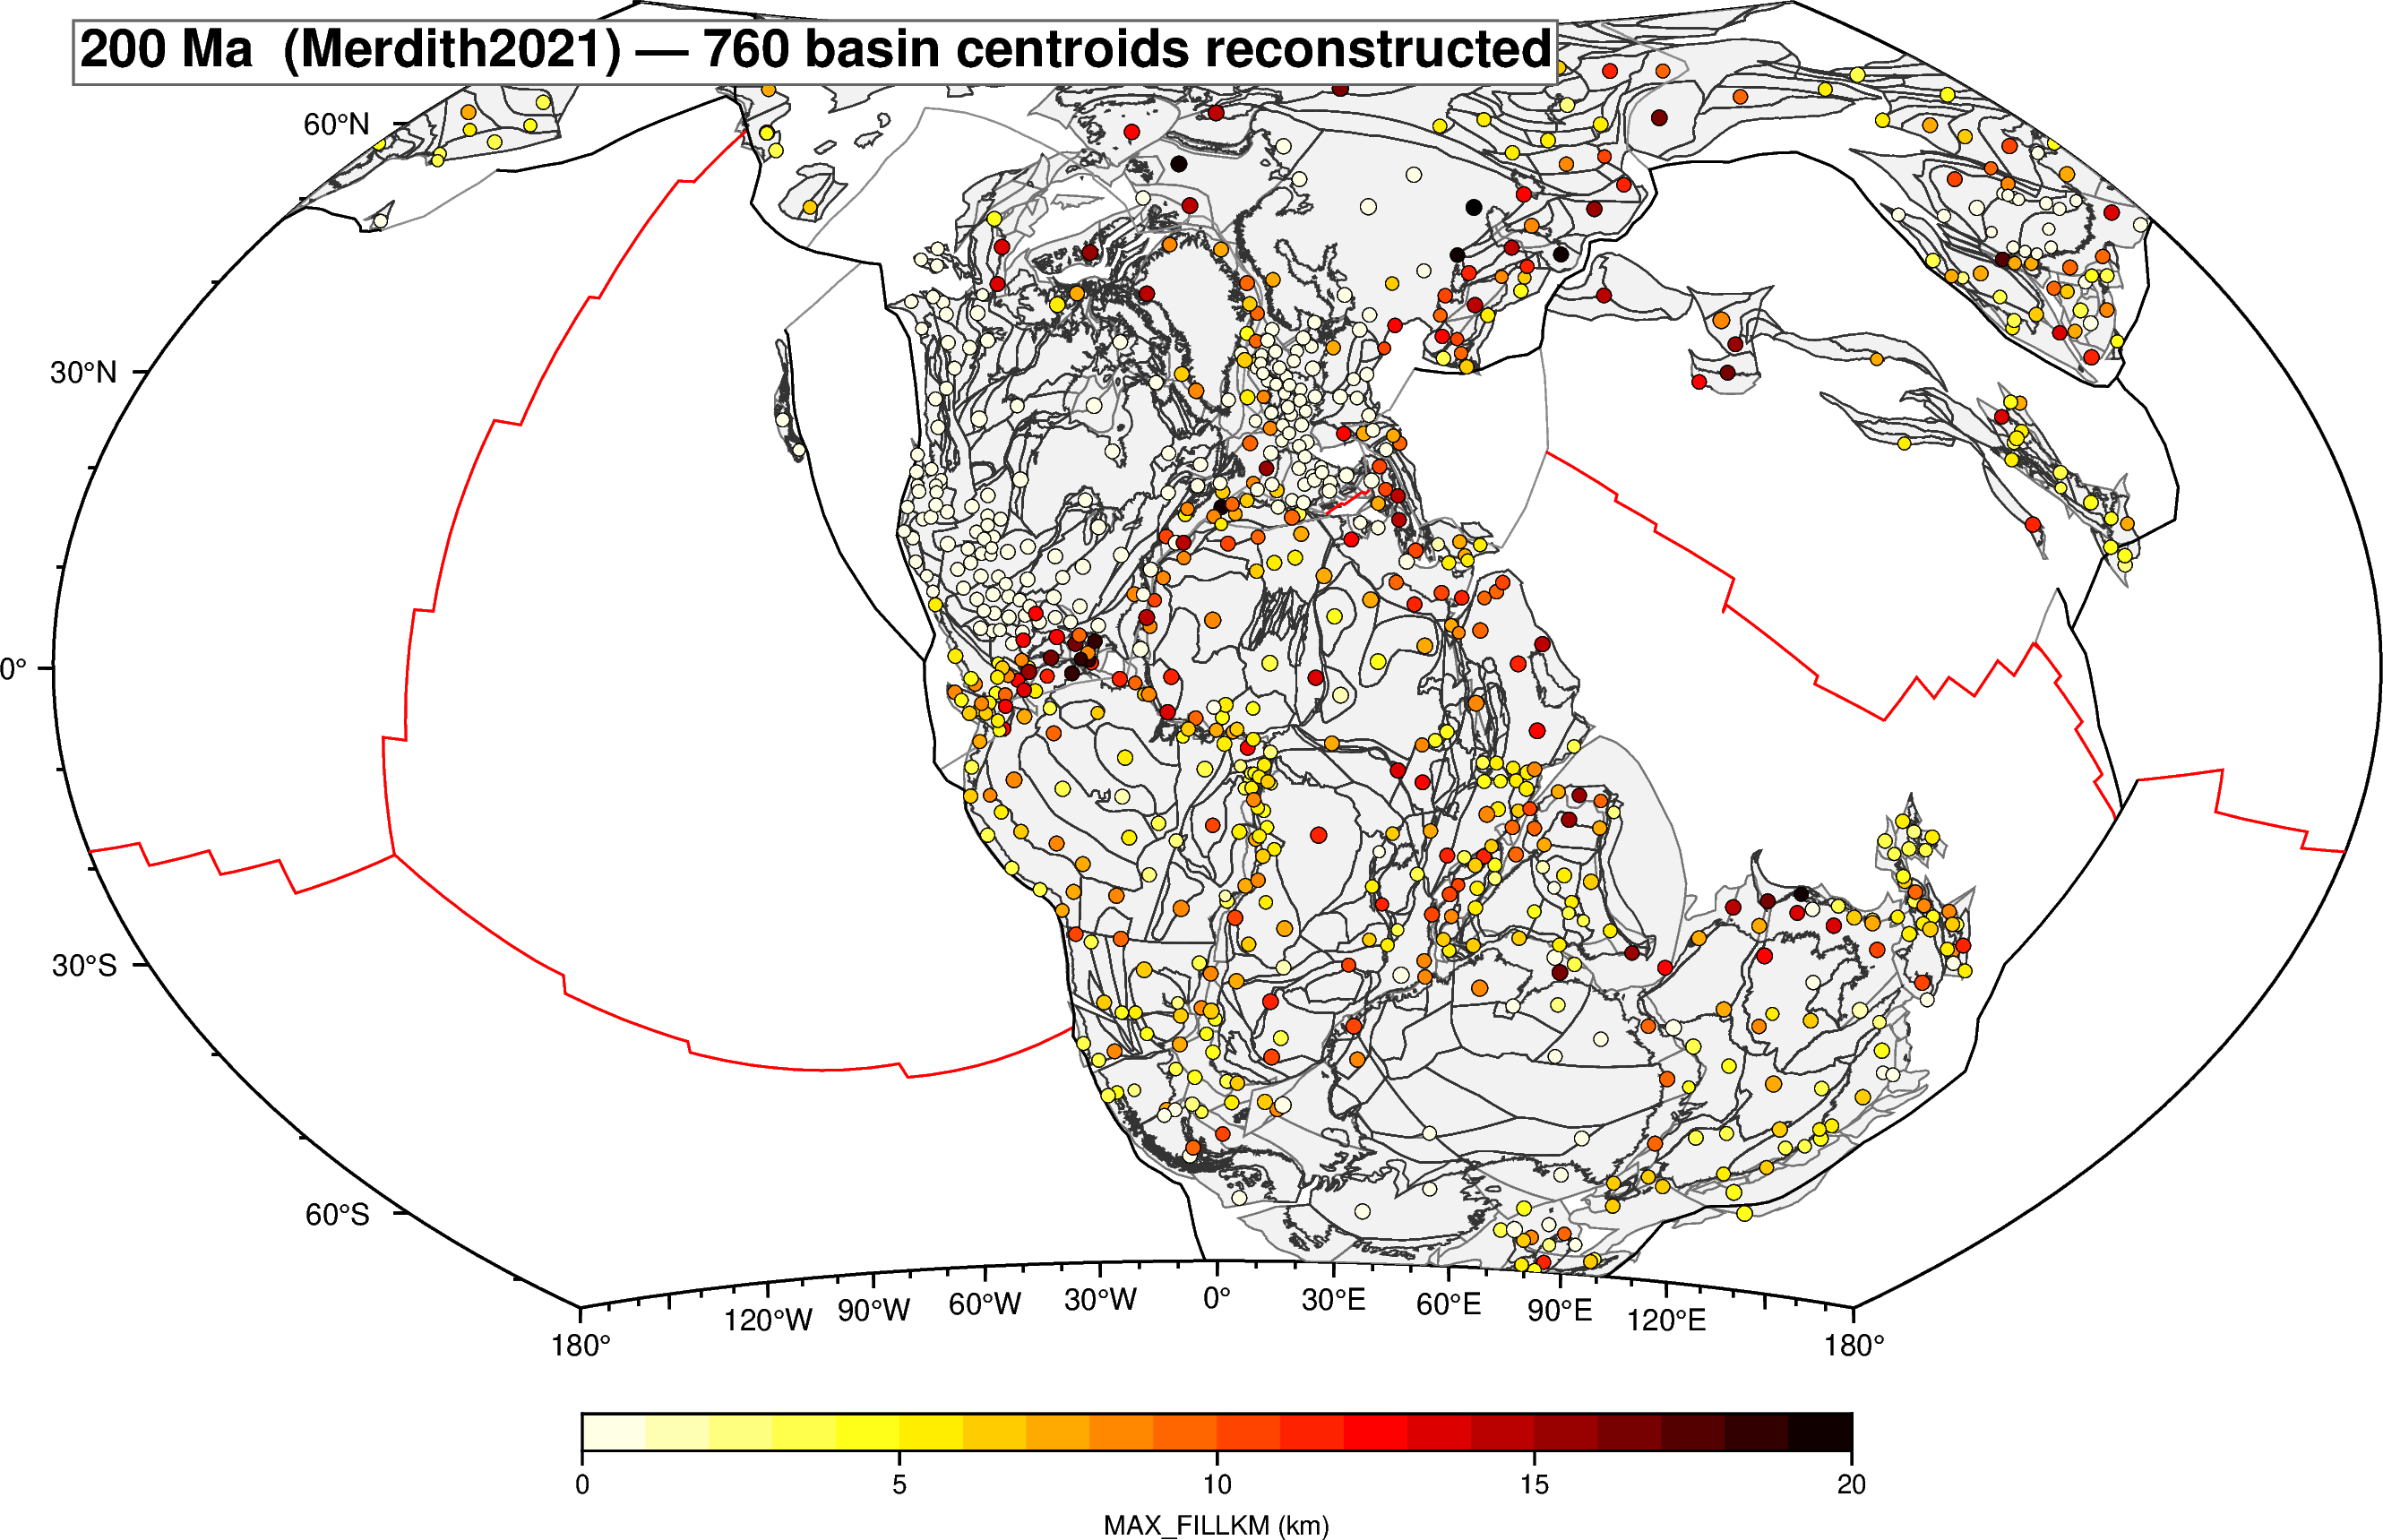

In [9]:
# Compute basin centroids in modern coords
basins["cent_lon"] = basins.geometry.centroid.x
basins["cent_lat"] = basins.geometry.centroid.y

# Set up plate reconstruction + reconstruct centroids
pmm   = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="data/pmm_cache")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
)

# ----------------------------------------------------------------------------
# Plate-ID assignment — canonical GPlates PlatePartitioner over StaticPolygons.
#
# Merdith 2021 has 850 continental-only polygons but 2391 STATIC polygons that
# cover the entire globe (including rifted-margin and oceanic segments). Using
# ContinentalPolygons alone leaves offshore basins with pid=None — they end
# up either unrotated (visually "floating in the ocean at reconstruction age")
# or forced onto a distant continental terrane by a nearest-boundary fallback.
#
# StaticPolygons + PlatePartitioner is the canonical GPlates approach. Every
# point on Earth resolves to a well-defined plate ID under the Merdith
# rotation model, and offshore basins ride the appropriate margin/oceanic
# plate with the correct paleo-position.
# ----------------------------------------------------------------------------
_static_features = list(pygplates.FeaturesFunctionArgument(
    model.get_static_polygons()).get_features())
_rotation_model  = pygplates.RotationModel(model.get_rotation_model())
_partitioner     = pygplates.PlatePartitioner(_static_features, _rotation_model)
print(f"  PlatePartitioner ready with {len(_static_features)} static polygons")

def assign_plate_ids(lons, lats):
    """Return int array of plate IDs from the Merdith static-polygon
    partition. Any point that fails to partition (extremely rare — poles
    only) gets pid=0 which stays fixed under any rotation."""
    pids = np.zeros(len(lons), dtype=int)
    for i, (lon, lat) in enumerate(zip(lons, lats)):
        pt = pygplates.PointOnSphere(float(lat), float(lon))
        partitioning_plate = _partitioner.partition_point(pt)
        if partitioning_plate is not None:
            pids[i] = int(partitioning_plate.get_feature().get_reconstruction_plate_id())
    return pids

# Assign a real plate ID to every basin centroid — offshore centroids that
# fall outside static polygons get their nearest continental plate assigned
# via the nearest-polygon fallback, so they don\'t float in the ocean.
print(f"  assigning plate IDs to {len(basins)} basin centroids...")
_basin_pids = assign_plate_ids(basins["cent_lon"].to_numpy(),
                                basins["cent_lat"].to_numpy())
_n_zero = int((_basin_pids == 0).sum())
print(f"  {_n_zero} of {len(basins)} basins on plate 0 (true stationary anchor)")

gpts  = gplately.Points(recon,
                        basins["cent_lon"].to_numpy(),
                        basins["cent_lat"].to_numpy(),
                        plate_id=_basin_pids,
                        anchor_plate_id=ANCHOR_PLATE_ID)
plons, plats = gpts.reconstruct(float(PALEO_AGE_MA),
                                return_array=True,
                                anchor_plate_id=ANCHOR_PLATE_ID)
basins["paleo_lon"] = plons
basins["paleo_lat"] = plats

recon_ok = basins.dropna(subset=["paleo_lon", "paleo_lat"]).copy()

# ---- Drop backdrop basins that land in the open ocean at this age ----
# (their reconstruction is technically correct — some basins DID form on
# oceanic crust — but showing them as bare dots over blue ocean reads as
# "reconstruction failed". We restrict to basins whose paleo-position sits
# inside a reconstructed continental polygon.)
_cont_recon_at_age = []
_cf = list(pygplates.FeaturesFunctionArgument(
    model.get_layer("ContinentalPolygons")).get_features())
_rr = []
pygplates.reconstruct(_cf, _rotation_model, _rr, float(PALEO_AGE_MA),
                      anchor_plate_id=ANCHOR_PLATE_ID)
for _r in _rr:
    _g = _r.get_reconstructed_geometry()
    if isinstance(_g, pygplates.PolygonOnSphere):
        _cont_recon_at_age.append(_g)
_on_land = np.zeros(len(recon_ok), dtype=bool)
for _i, (_lo, _la) in enumerate(zip(recon_ok["paleo_lon"].to_numpy(),
                                     recon_ok["paleo_lat"].to_numpy())):
    _pt = pygplates.PointOnSphere(float(_la), float(_lo))
    for _pg in _cont_recon_at_age:
        if _pg.is_point_in_polygon(_pt):
            _on_land[_i] = True; break
_n_off = int((~_on_land).sum())
recon_ok = recon_ok.loc[_on_land].copy()
print(f"  {len(recon_ok)} of {len(basins)} basin centroids on paleo-continental "
      f"crust at {PALEO_AGE_MA:.0f} Ma (dropped {_n_off} offshore/oceanic-crust)")

# Set up PlotTopologies for the paleogeographic base
gplot = gplately.PlotTopologies(
    plate_reconstruction=recon,
    coastlines=model.get_layer("Coastlines"),
    continents=model.get_layer("ContinentalPolygons"),
    plot_engine=gplately.PygmtPlotEngine(),
    time=float(PALEO_AGE_MA),
    anchor_plate_id=ANCHOR_PLATE_ID,
)

fig = pygmt.Figure()
fig.basemap(region=REGION, projection=PROJ, frame="af")
gplot.plot_continents(fig, fill="gray95", pen="0.4p,gray45")
gplot.plot_coastlines(fig, pen="0.4p,gray20")
try:
    gplot.plot_all_topological_sections(fig, pen="0.4p,gray55")
    gplot.plot_ridges(fig, pen="0.6p,red")
    gplot.plot_trenches(fig, pen="0.6p,black")
except Exception as _e:
    print(f"  topology overlay skipped: {_e}")

# Reconstructed basin centroids — size ∝ log(area), colour ∝ MAX_FILLKM
import tempfile
_fd, cent_cpt = tempfile.mkstemp(suffix=".cpt", prefix="T75_paleo_cent_")
os.close(_fd)
pygmt.makecpt(cmap="hot", series=[0, 20, 1], reverse=True, output=cent_cpt)

sizes = 0.06 + 0.10 * np.log10(np.clip(recon_ok["AREA_KM2"], 100, 5e6)) / 6.7
xyz = np.column_stack([
    recon_ok["paleo_lon"].to_numpy(),
    recon_ok["paleo_lat"].to_numpy(),
    recon_ok["MAX_FILLKM"].fillna(0).to_numpy(),
    sizes.values,
])
fig.plot(data=xyz, style="cc", cmap=cent_cpt, pen="0.2p,black")
fig.colorbar(cmap=cent_cpt,
             frame=["a5", "x+lMAX_FILLKM (km)"],
             position="JBC+w12c/0.35c+h+o0/1c")

fig.text(text=f"{PALEO_AGE_MA:.0f} Ma  ({MODEL_NAME}) — {len(recon_ok)} basin centroids reconstructed",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
fig.show(width=1000)


### How to read the paleogeographic map

Every dot is one modern-day sedimentary basin, reconstructed to its position at PALEO_AGE_MA via Merdith 2021. Symbol size is proportional to log(area) — a huge dot is a continental-scale basin. Colour is MAX_FILLKM: pale yellow = shallow-fill basins, dark red = 15+ km fills (rare — some Precambrian intracratonic sags, some deep passive-margin basins).

At **200 Ma** (Early Jurassic), the North Atlantic conjugate rift-margin basins cluster along the tight join between eastern North America and NW Africa. The Central Atlantic basins hug the future Central Atlantic Magmatic Province margins. Circum-Tethys basins line the northern margin of Gondwana. This is a first look; deeper analyses via `gplately.Points` on the polygon boundaries (rather than centroids) would reveal how basin shapes evolved through rifting.

Try changing `PALEO_AGE_MA` in the CONFIGURATION cell to explore other epochs — 300 Ma (mid-Permian, Pangea assembly), 100 Ma (mid-Cretaceous), 50 Ma (Palaeocene–Eocene). The rate at which basins cluster / disperse through time is a direct proxy for continental rifting/collision episodes.

## Extend this

- **Reconstruct polygons, not centroids.** For every basin, densify its boundary with `shapely.LineString.interpolate` and reconstruct each vertex individually via `gplately.Points`. That gives you the FULL basin outline at PALEO_AGE_MA — the paleo-shape reveals rift-to-drift asymmetry, breakup obliquity, and basin fragmentation.
- **Sweep through time.** Loop PALEO_AGE_MA ∈ [0, 10, 20, ...] to animate basin trajectories. Basin dots that migrate together are on the same plate; dots that diverge mark rifting; dots that converge mark collision.
- **Backstrip sediment thickness.** Use the `pyBacktrack` library on the per-basin mean sediment thickness column to compute subsidence history, water depth, and thermal-tectonic subsidence. Add the resulting β-factor as a new column.
- **Cross-reference with T54.** T54 computes a global stretching-factor field β = t_c0 / t_c from the same Afonso crustal-thickness grid. Overlay T54's β field on top of this notebook's basin polygons — you'll see that high-β cells cluster inside the mapped rift basins.
- **Filter by SUB_REGIME.** The `SUB_REGIME` column classifies basins by tectonic setting (intracratonic sag, passive margin, foreland, back-arc, etc.). Split the paleo-map into sub-panels by regime.
- **Compare against the pre-2012 ICONS PostGIS workflow.** Christian Heine's original ICONS Atlas (2005–2009) computes backstripped β-factors from well data in a PostgreSQL database. The `Public_github_material/ICONS_Atlas/ICONS/` folder in this suite has the Python 2 GMT4 scripts as a historical reference — see `6-analyser.py` in particular.

## Related notebooks

- **T54** — β-factor field from Afonso crustal thickness. Sibling notebook using the same crustal-thickness grid but from the crustal-thinning perspective.
- **T12** — retrodeforming a global lithospheric-thickness grid through deep time. Uses `TopologicalModel.reconstruct_geometry` on gridded fields, complementary to this notebook's point-reconstruction approach.
- **T16** — subducted-slab flux inventory. Different data type (trench points, not basin polygons), same GPlately point-reconstruction pattern.

## References

- Heine, C. (2007). Formation and Evolution of Intracontinental Sedimentary Basins. PhD thesis, EarthByte Group, University of Sydney. — origin of the 870-basin ICONS Atlas polygon compilation.
- Heine, C. & Müller, R.D. (2008). The IntraCONtinental basinS (ICONS) atlas — applications in eastern Australia. In: Blevin, J.E., Bradshaw, B.E. & Uruski, C. (Eds), *Eastern Australasian Basins Symposium III*, Petroleum Exploration Society of Australia, Special Publication, 275-290.
- Heine, C., Müller, R.D., Steinberger, B. & Torsvik, T.H. (2008). Subsidence in intracontinental basins due to dynamic topography. *Physics of the Earth and Planetary Interiors* 171(1-4), 252-264. doi:10.1016/j.pepi.2008.05.008.
- Heine, C., Zoethout, J., & Müller, R.D. (2013). Kinematics of the South Atlantic rift. *Solid Earth* 4, 215-253. https://doi.org/10.5194/se-4-215-2013
- Bird, D.E. & Mooney, W.D. (2026). GST-1: A high-resolution global sediment thickness model. *Tectonophysics*, p.231175.
- Afonso, J.C., Salajegheh, F., Szwillus, W., Ebbing, J., & Gaina, C. (2019). A global reference model of the lithosphere and upper mantle from joint inversion and analysis of multiple data sets. *Geophysical Journal International* 217(3), 1602-1628. https://doi.org/10.1093/gji/ggz094
- Mather, B.R., Müller, R.D., Zahirovic, S., et al. (2024). Deep time spatio-temporal data analysis using GPlately. *Geoscience Data Journal* 11, 3-10. https://doi.org/10.1002/gdj3.185
- Merdith, A.S., et al. (2021). Extending full-plate tectonic models into deep time. *Earth-Science Reviews* 214, 103477. https://doi.org/10.1016/j.earscirev.2020.103477
